<a href="https://colab.research.google.com/github/radubhattarai/Hands-on-LLM/blob/main/Chapter_1_LLM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1> Learning LLM from <b> "Hands on Large Language Model" </b> book by Jay Alammar and Maarten Grootendorst

Giving myself 90 days to stop just using AI and actually learn how to build it.



---

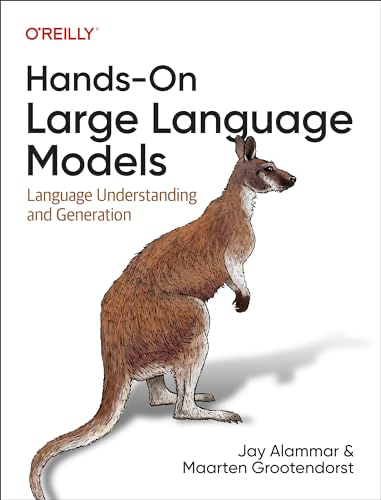

**Chapter 1 - Introduction to Language Models**

The first step is to load our model onto the GPU for faster inference. Note that we load the model and tokenizer separately (although that isn't always necessary).

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer

# Load model and tokenizer
model = AutoModelForCausalLM.from_pretrained(
    "microsoft/Phi-3-mini-4k-instruct",
    device_map="cuda",
    torch_dtype="auto",
    trust_remote_code=False,
)
tokenizer = AutoTokenizer.from_pretrained("microsoft/Phi-3-mini-4k-instruct")

Although we can now use the model and tokenizer directly, it's much easier to wrap it in a pipeline object:

In [ ]:
from transformers import pipeline

# Create a pipeline
generator = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    return_full_text=False,
    max_new_tokens=500,
    do_sample=False
)

In [ ]:
# The prompt (user input / query)
messages = [
    {"role": "user", "content": "Tell me one joke about CAT"}
]

# Generate output
output = generator(messages)
print(output[0]["generated_text"])